In [1]:
import matplotlib.pyplot as plt
import pandas as pd

base_abc = pd.read_csv("Base_ABC_Flor-Colheita.csv")

In [2]:
#variaveis utilizadas

variaveis = [ 
    "UF",
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Altitude Média [classe]",
    "Semeadura [data]",
    "Colheita [data]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Genótipos",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "NH.UR > 90 [sum]",
    "Ciclo Semeadura-Colheita [dias]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Inseticida Planejado [aplicações]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "Colheita [decendio]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "Semeadura [decendio]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
]

base_abc_X  = base_abc[variaveis].copy()
base_abc_Y = base_abc["Produtividade Realizada [kg/ha]"]

#transformando as datas
base_abc_X["Semeadura [data]"] = pd.to_datetime(base_abc_X["Semeadura [data]"], errors='coerce')
base_abc_X["Colheita [data]"] = pd.to_datetime(base_abc_X["Colheita [data]"], errors='coerce')

for col in ["Semeadura [data]", "Colheita [data]"]:
    base_abc_X[f"{col}_ano"] = base_abc_X[col].dt.year
    base_abc_X[f"{col}_mes"] = base_abc_X[col].dt.month
    base_abc_X[f"{col}_dia"] = base_abc_X[col].dt.day


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

variaveis_categoricas = [
    "UF",
    "Altitude Média [classe]",
    "Genótipos Propósito",
    "Tipo Safra",
    "Solo Textura",
    "Talhão",
    "Solo Grupo",
    "Genótipos"
]

variaveis_numericas = [
    "NH.TMED < 10 [sum]",
    "ND.TMIN < 10 [sum]",
    "Amplitude Térmica [soma]",
    "Temperatura Ar Mínima [soma]",
    "Temperatura Ar Máxima [soma]",
    "Fotoperiodo [soma]",
    "Precipitação [soma]",
    "Graus Dias [soma]",
    "Temperatura Ar [soma]",
    "Umidade Relativa Máxima [soma]",
    "Umidade Relativa Mínima [soma]",
    "Umidade Relativa [soma]",
    "Radiação Solar [soma]",
    "Evapotranspiração Potencial PM [soma]",
    "Evapotranspiração Potencial PM2 [soma]",
    "Temperatura Orvalho [soma]",
    "Temperatura Ar Noturna [ºC]",
    "Temperatura Molhamento Foliar [soma]",
    "NH.UR > 90 [sum]",
    "ND.UR < 60 [sum]",
    "ND.UR > 80 [sum]",
    "ND.UR > 90 [sum]",
    "NH.UR < 60 [sum]",
    "Talhão Latitude [grau decimal]",
    "Talhão Longitude [grau decimal]",
    "ND.RAD < 10 [sum]",
    "ND.PREC > 5 [sum]",
    "NH.RAD > 800 [sum]",
    "ND.PREC = 0.0 [sum]",
    "ND.TMAX > 30 [sum]",
    "ND.PREC > 0.2 [sum]",
    "ND.RAD > 20 [sum]",
    "NH.RAD > 1000 [sum]",
    "NH.RAD > 600 [sum]",
    "Semeadura [data]_ano",
    "Semeadura [data]_mes",
    "Semeadura [data]_dia",
    "Colheita [data]_ano",
    "Colheita [data]_mes",
    "Colheita [data]_dia",
    "Colheita [decendio]",
    "Semeadura [decendio]",
    "Inseticida Planejado [aplicações]",
    "Fungicida Planejado [aplicações]",
    "Herbicida Planejado [aplicações]",
    "Altitude Máxima [m]",
    "Altitude Média [m]",
    "Altitude Mínima [m]",
    "Ciclo Semeadura-Colheita [dias]",
]

#transforma valores que estavam sendo interpretados como str em valores numericos
for col in variaveis_numericas:
    if base_abc_X[col].dtype == "object":
        base_abc_X[col] = (
            base_abc_X[col].str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False)
            .astype(float)
        )

pipeline_numericas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean'))  # preenche valores vazios com a média
])

pipeline_categoricas = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # preenche valores vazios com o valor mais comum
    ('onehot', OneHotEncoder(handle_unknown='ignore'))  
])

preprocessador = ColumnTransformer(transformers=[
    ('num', pipeline_numericas, variaveis_numericas),
    ('cat', pipeline_categoricas, variaveis_categoricas)
])

In [4]:
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

mlp = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', MLPRegressor())
])

knn = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('regressor', KNeighborsRegressor(n_neighbors = 3))
])

decision_tree = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', DecisionTreeRegressor())
])

random_forest = Pipeline(steps=[
    ('preprocessamento', preprocessador),
    ('scaler', StandardScaler(with_mean=False)),
    ('regressor', RandomForestRegressor())
])

In [5]:
mlp.fit(base_abc_X, base_abc_Y)

,steps,"[('preprocessamento', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [6]:
knn.fit(base_abc_X, base_abc_Y)

,steps,"[('preprocessamento', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [7]:
decision_tree.fit(base_abc_X, base_abc_Y)

,steps,"[('preprocessamento', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
random_forest.fit(base_abc_X, base_abc_Y)

,steps,"[('preprocessamento', ...), ('scaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [9]:
decision_tree_importance = decision_tree.named_steps['regressor'].feature_importances_ #dessa forma pois é um pipeline

In [10]:
import numpy as np

# Pegar nomes das features após preprocessador
dt_onehot = decision_tree.named_steps['preprocessamento'].named_transformers_['cat'].named_steps['onehot']
dt_categorical_expanded_names = dt_onehot.get_feature_names_out(variaveis_categoricas)

dt_feature_names = np.concatenate([variaveis_numericas, dt_categorical_expanded_names])

dt_df_importances = pd.DataFrame({
    'feature_expanded': dt_feature_names,
    'importance': decision_tree_importance
})

# Pega o nome da variável antes do _ e agrupa
# Ex: Solo Grupo_A -> Solo Grupo
dt_df_importances['feature_original'] = dt_df_importances['feature_expanded'].apply(
    lambda x: x.split('_')[0] if x.split('_')[0] in variaveis_categoricas else x
)

dt_df_grouped = dt_df_importances.groupby('feature_original')['importance'].sum()
dt_df_grouped = dt_df_grouped.sort_values(ascending=False)

print(dt_df_grouped)

feature_original
Talhão Latitude [grau decimal]            0.215462
Genótipos                                 0.051191
Talhão Longitude [grau decimal]           0.050222
Talhão                                    0.041513
Altitude Mínima [m]                       0.035941
ND.TMAX > 30 [sum]                        0.030128
Precipitação [soma]                       0.028096
Fungicida Planejado [aplicações]          0.026118
Colheita [data]_dia                       0.025613
NH.UR > 90 [sum]                          0.024073
Temperatura Ar Mínima [soma]              0.023023
ND.PREC = 0.0 [sum]                       0.021907
Fotoperiodo [soma]                        0.021622
NH.RAD > 800 [sum]                        0.021121
Altitude Máxima [m]                       0.019924
Amplitude Térmica [soma]                  0.019576
ND.RAD > 20 [sum]                         0.019502
ND.PREC > 0.2 [sum]                       0.018704
ND.RAD < 10 [sum]                         0.018475
Herbicida Plan

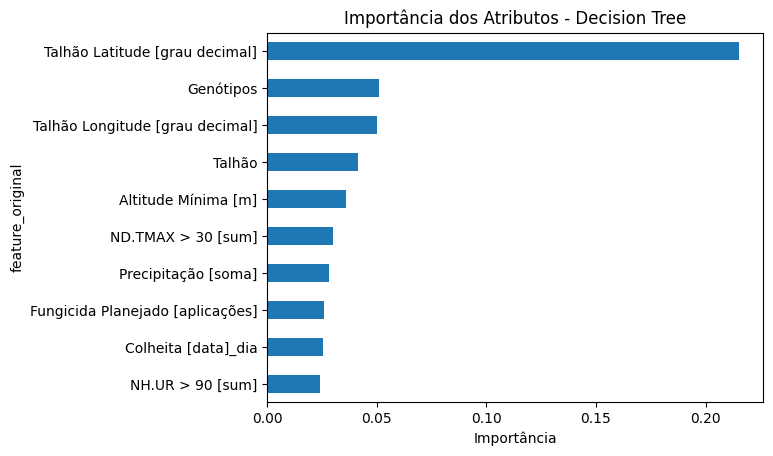

In [11]:
dt_df_grouped.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - Decision Tree")
plt.xlabel("Importância")
plt.show()

In [12]:
random_forest_importance = random_forest.named_steps['regressor'].feature_importances_

In [13]:
rf_onehot = random_forest.named_steps['preprocessamento'].named_transformers_['cat'].named_steps['onehot']
rf_categorical_expanded_names = rf_onehot.get_feature_names_out(variaveis_categoricas)

rf_feature_names = np.concatenate([variaveis_numericas, rf_categorical_expanded_names])

rf_df_importances = pd.DataFrame({
    'feature_expanded': rf_feature_names,
    'importance': random_forest_importance
})

rf_df_importances['feature_original'] = rf_df_importances['feature_expanded'].apply(
    lambda x: x.split('_')[0] if x.split('_')[0] in variaveis_categoricas else x
)

rf_df_grouped = rf_df_importances.groupby('feature_original')['importance'].sum()
rf_df_grouped = rf_df_grouped.sort_values(ascending=False)

print(rf_df_grouped)

feature_original
Talhão Latitude [grau decimal]            0.199450
Talhão Longitude [grau decimal]           0.071594
Talhão                                    0.064380
Genótipos                                 0.061646
Altitude Mínima [m]                       0.037811
Precipitação [soma]                       0.025327
Colheita [data]_dia                       0.022266
Altitude Máxima [m]                       0.020668
Altitude Média [m]                        0.019892
Herbicida Planejado [aplicações]          0.019579
NH.UR < 60 [sum]                          0.018931
Semeadura [data]_dia                      0.018571
Fungicida Planejado [aplicações]          0.018326
NH.RAD > 1000 [sum]                       0.017736
ND.TMAX > 30 [sum]                        0.017541
Genótipos Propósito                       0.017356
ND.RAD < 10 [sum]                         0.017323
Inseticida Planejado [aplicações]         0.016828
Amplitude Térmica [soma]                  0.016110
Colheita [dece

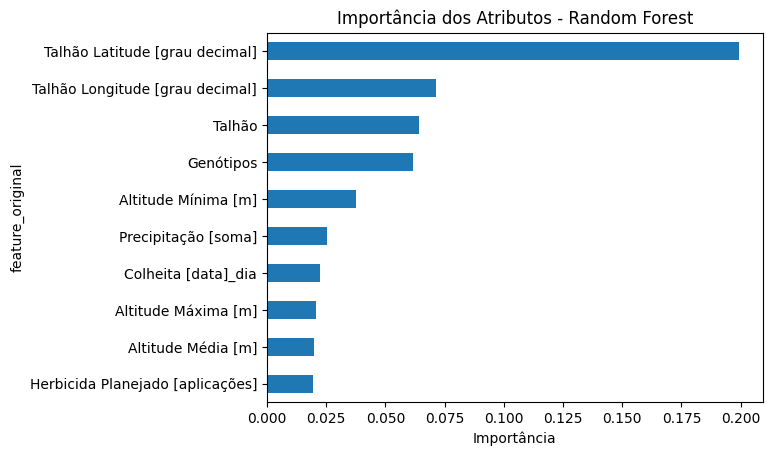

In [14]:
rf_df_grouped.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - Random Forest")
plt.xlabel("Importância")
plt.show()

In [15]:
from sklearn.inspection import permutation_importance

mlp_importance = permutation_importance(mlp, base_abc_X, base_abc_Y, scoring="neg_mean_squared_error")

In [16]:
knn_importance = permutation_importance(knn, base_abc_X, base_abc_Y, scoring="neg_mean_squared_error")

In [17]:
print(mlp_importance.importances_mean)

[ 3.96011353e-03  2.54605073e-03  5.61572580e-03  2.73111897e-02
  0.00000000e+00  0.00000000e+00  2.51940761e-03  0.00000000e+00
  3.67421821e-03  1.11348824e+00  2.50883105e-02  8.02684841e-04
  2.01219140e-04  6.42374290e-04  6.81588985e-04  1.20943685e-01
  2.29971226e-03 -3.60731185e-06  3.27987438e-03  1.11654782e-03
  3.96857273e-04  5.82770087e-04 -3.45011816e-07  7.88213714e-04
  3.43784643e-03  1.51162899e-04  7.40958162e-04  4.38570640e-04
  3.14986080e-03  1.23356551e-05  7.06879427e-04  9.18861116e-04
 -4.16154266e-06  1.75763915e-03 -1.39630407e-05  2.98085586e-04
  2.07712651e-03  1.06392848e-04  1.43065969e-03  5.68376650e-04
  4.88334111e-05  1.77588730e-03  1.49528616e-03  1.83295750e-03
  1.12792226e-03  5.59223108e-03  6.62784234e-04  1.80041596e-04
  8.95875632e-04  1.12326389e-03  4.94321925e-05  2.94674946e-05
  7.51200451e-04  0.00000000e+00  2.54892123e-03  1.15948538e-04
  0.00000000e+00  7.09950435e-06  3.47426212e-05]


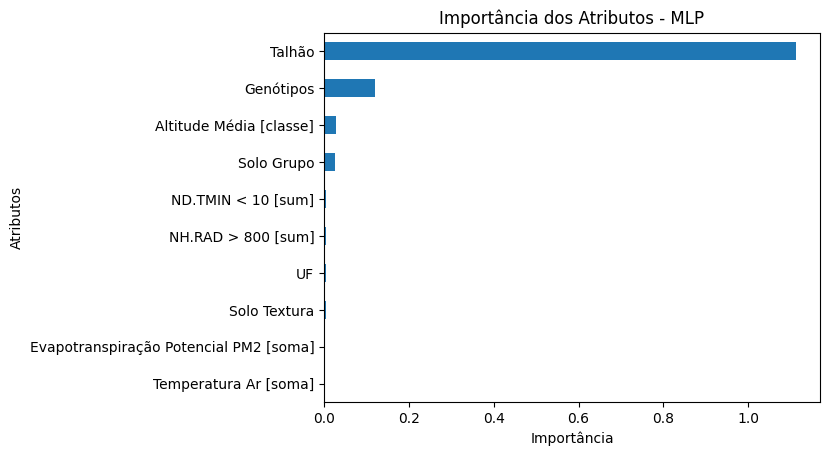

In [28]:
mlp_df_importances = pd.DataFrame({
    "feature": base_abc_X.columns,
    "importance": mlp_importance.importances_mean
})

mlp_top_10 = (
    mlp_df_importances
    .sort_values(by="importance", ascending=False)
    .head(10)
)

mlp_top_10.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - MLP")
plt.xlabel("Importância")
plt.ylabel("Atributos")
plt.show()

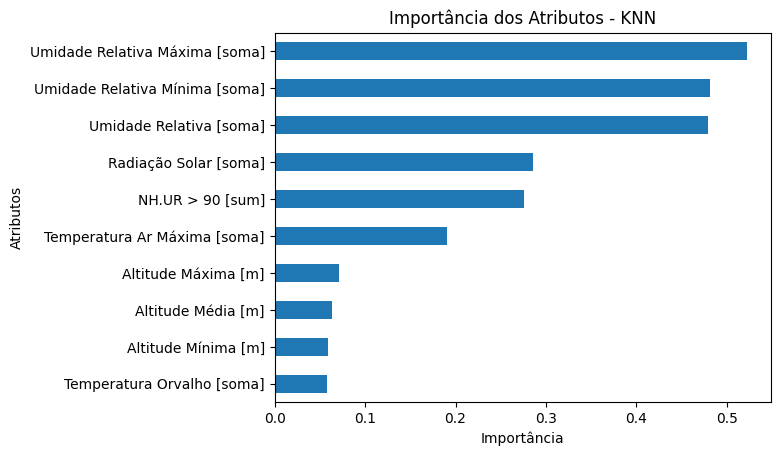

In [26]:
knn_df_importances = pd.DataFrame({
    "feature": base_abc_X.columns,
    "importance": knn_importance.importances_mean
})

knn_top_10 = (
    knn_df_importances
    .sort_values(by="importance", ascending=False)
    .head(10)
)

knn_top_10.plot(
    kind="barh",
    x="feature",
    y="importance",
    legend=False
)

plt.gca().invert_yaxis()
plt.title("Importância dos Atributos - KNN")
plt.xlabel("Importância")
plt.ylabel("Atributos")
plt.show()